# Análise de Sobrevivência do Tempo até a Evasão de uma Coorte de Estudantes

## Resumo Executivo

**Contexto.** Um escritório de pesquisa institucional de uma faculdade de quatro anos quer entender *quando*, e não apenas *se*, os estudantes saem. Uma coorte de calouros é acompanhada semestre a semestre desde a matrícula; alguns se formam, alguns evadem, e alguns ainda estão matriculados quando a janela de observação se encerra. Como o desfecho dos estudantes ainda matriculados é desconhecido (censurado à direita), e como a formatura remove um estudante do conjunto de risco sem ser uma evasão, a regressão comum de aprovação/reprovação descarta a informação de tempo e enviesa qualquer estimativa que ignore a censura. A ferramenta correta é a **análise de tempo até o evento (sobrevivência)**, na qual o evento de interesse é a **evasão** e o relógio é medido em semestres acadêmicos cursados.

**Questão de negócio.** A **situação acadêmica no primeiro semestre** de um estudante (uma sinalização de alerta precoce) separa as trajetórias de tempo até a evasão da coorte, e quais características do estudante impulsionam o risco de evasão após ajuste? As respostas alimentam um sistema de alerta precoce: estudantes cujo risco estimado de evasão é alto devem receber acompanhamento de orientação em seus primeiros semestres, quando a intervenção é mais barata e mais eficaz.

**Abordagem.** Simulamos uma coorte de 100 estudantes inline (sem dados externos) e, em seguida, percorremos um fluxo de trabalho padrão de sobrevivência:

1. **PROC MEANS** traça o perfil dos preditores entre os três desfechos observados (Formado / Evadido / ainda Matriculado) para confirmar que o sinal simulado se comporta de forma sensata.
2. **PROC FREQ** cruza a situação acadêmica do primeiro semestre com o desfecho, com um teste qui-quadrado de associação.
3. **PROC UNIVARIATE** reporta percentis robustos do tempo até a evasão por situação.
4. **PROC LIFETEST** estima curvas de evasão de Kaplan-Meier estratificadas por situação e executa testes de igualdade **log-rank** e **Wilcoxon**.
5. **PROC PHREG** ajusta um modelo multivariável de **riscos proporcionais de Cox** para o risco de evasão, com um efeito `CLASS` codificado por referência, tratamento de empates de Efron e intervalos de confiança de limite de risco.

**O que os dados mostram.** Dos 100 estudantes simulados, **49 evadiram, 49 se formaram e 2 permaneceram matriculados** no corte de 12 semestres. Estudantes sinalizados com **advertência acadêmica** em seu primeiro semestre (GPA do primeiro semestre abaixo de 2.5) evadem muito mais rápido do que estudantes em boa situação: tempo mediano até a evasão de **3.8 semestres vs 8.7 semestres**, uma separação que o teste log-rank confirma (qui-quadrado = 10.73, *p* = 0.0011). O modelo de Cox identifica o GPA do primeiro semestre (razão de risco 0.21 por ponto de GPA, *p* < 0.0001), o GPA do ensino médio (HR 0.45, *p* = 0.027) e a condição de primeira geração (HR 2.03, *p* = 0.031) como impulsionadores ajustados significativos da evasão, enquanto a condição de bolsa Pell não é significativa uma vez controlado o GPA (HR 0.95, *p* = 0.85).

> *Todos os números são ilustrativos e gerados a partir de dados sintéticos; não são registros reais de estudantes. Este ambiente é executado sem licença, portanto a coorte é dimensionada em 100 estudantes.*

## Fontes de Dados

Todos os dados são **sintéticos**, gerados inline no primeiro DATA step com `CALL STREAMINIT(20260611)` e a função `RAND`. Sem arquivos externos ou acesso à rede. Uma linha por estudante simulado.

**Conjunto de dados `matriculas`** (100 linhas, uma linha por estudante)

| Variável | Tipo | Descrição | Distribuição geradora |
|----------|------|-------------|--------------------------|
| `id_aluno` | Num | Chave única do estudante | sequência 1–100 |
| `primeira_geracao` / `rotulo_geracao` | Num / Char | Sinalização de primeira geração (0/1) e rótulo | Bernoulli, ~42% |
| `bolsa_pell` | Num | Sinalização de bolsa Pell (necessidade financeira) (0/1) | Bernoulli, ~42% |
| `programa` | Char | STEM / BUS / HUM | categórica (~42% / 32% / 26%) |
| `gpa_ensino_medio` | Num | GPA do ensino médio (1.8–4.0) | Normal(3.00, 0.42), limitada |
| `gpa_semestre1` | Num | GPA universitário do primeiro semestre (0–4.0) | f(gpa_ensino_medio, programa) + ruído Normal |
| `situacao_academica` | Char | Situação acadêmica do primeiro semestre | `gpa_semestre1 < 2.5` → Advertência acadêmica, senão Boa situação |
| `tempo_semestres` | Num | Semestres cursados até o evento ou censura | sorteios Weibull concorrentes; limitado a 12 |
| `evadiu` | Num | Indicador do evento de evasão (1 = evadiu, 0 = censurado) | derivado |
| `desfecho` | Char | Formado / Evadido / Matriculado | derivado dos sorteios concorrentes |

Um preditor linear latente na escala logarítmica liga a **taxa de evasão** de cada estudante ao GPA do primeiro semestre, ao GPA do ensino médio, à condição de primeira geração e à necessidade financeira, de modo que os preditores carregam um sinal genuíno, porém ruidoso. A evasão e a formatura são sorteadas como tempos latentes **concorrentes** (Weibull); o que ocorrer primeiro dentro de uma janela de 12 semestres torna-se o desfecho observado, e os estudantes que atingem o semestre 12 sem nenhum dos dois são censurados à direita. Para os modelos de sobrevivência, o **evento é a evasão** (`evadiu = 1`); a formatura e a matrícula em andamento são ambas tratadas como censura (`evadiu = 0`).

## 1. Simular a coorte de estudantes

A primeira célula constrói uma coorte sintética de 100 estudantes. Um preditor linear latente na escala logarítmica vincula a taxa de evasão de cada estudante ao GPA do primeiro semestre, ao GPA do ensino médio, à condição de primeira geração e à condição Pell. A evasão e a formatura são geradas como tempos latentes **concorrentes** (sorteios Weibull); o que ocorrer primeiro dentro de uma janela de observação de 12 semestres torna-se o desfecho observado, e os estudantes que atingem o semestre 12 sem evadir ou se formar são censurados à direita. Um GPA do primeiro semestre abaixo de 2.5 sinaliza o estudante para **advertência acadêmica** — o sinal de alerta precoce que testamos na etapa de sobrevivência. Os sorteios aleatórios usam `CALL STREAMINIT` para reprodutibilidade e a função `RAND` entre as distribuições Uniforme, Normal e Weibull. Pisos e limites rígidos mantêm cada valor plausível (GPAs em 0–4.0).

In [1]:
DADOS matriculas;
    CHAMAR streaminit(20260611);
    COMPRIMENTO situacao_academica $24 rotulo_geracao $24 programa $4 desfecho $16;
    FAZER id_aluno = 1 ATÉ 100;
        /* Sinalizações de primeira geração e necessidade financeira */
        primeira_geracao = (rand("uniform") < 0.42);
        SE primeira_geracao ENTÃO rotulo_geracao = "Primeira geração";
        SENÃO              rotulo_geracao = "Geração continuada";
        bolsa_pell = (rand("uniform") < 0.42);

        /* Programa de estudo */
        v = rand("uniform");
        SE      v < 0.42 ENTÃO programa = "STEM";
        SENÃO SE v < 0.74 ENTÃO programa = "BUS";
        SENÃO                  programa = "HUM";

        /* Preparação acadêmica e desempenho no primeiro semestre */
        gpa_ensino_medio = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        gpa_semestre1 = round(MIN(4.0, MAX(0.0,
                     0.55*gpa_ensino_medio + 1.05 + 0.12*(programa="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Sinalização de alerta precoce: GPA do primeiro semestre abaixo de 2.5 = advertência acadêmica */
        SE gpa_semestre1 < 2.5 ENTÃO situacao_academica = "Advertência acadêmica";
        SENÃO                    situacao_academica = "Boa situação";

        /* Risco latente de evasão na escala logarítmica: GPA mais baixo,
           primeira geração e bolsa Pell aumentam a taxa de evasão. */
        eta = -1.05
             - 1.45*(gpa_semestre1 - 2.8)
             - 0.55*(gpa_ensino_medio - 3.0)
             + 1.05*primeira_geracao
             + 0.45*bolsa_pell;
        taxa_evasao = EXP(eta);

        /* Tempos latentes concorrentes (semestres): evasão vs formatura */
        t_evasao = rand("weibull", 1.2, 7.0) / MAX(0.30, taxa_evasao);
        t_formatura = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(gpa_semestre1 - 2.8));

        /* Janela administrativa de censura de 12 semestres */
        censura_em = 12;
        SE t_evasao <= t_formatura E_LÓGICO t_evasao <= censura_em ENTÃO FAZER;
            desfecho = "Evadido";   evadiu = 1; tempo_semestres = t_evasao;
        FIM;
        SENÃO SE t_formatura < t_evasao E_LÓGICO t_formatura <= censura_em ENTÃO FAZER;
            desfecho = "Formado"; evadiu = 0; tempo_semestres = t_formatura;
        FIM;
        SENÃO FAZER;
            desfecho = "Matriculado";  evadiu = 0; tempo_semestres = censura_em;
        FIM;
        tempo_semestres = round(tempo_semestres, 0.1);
        SAÍDA;
    FIM;
    MANTER id_aluno primeira_geracao rotulo_geracao bolsa_pell programa gpa_ensino_medio
         gpa_semestre1 situacao_academica tempo_semestres evadiu desfecho;
EXECUTAR;


NOTE: DATA matriculas


NOTE: Wrote matriculas (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Perfil dos preditores por desfecho observado

Antes de modelar, confirmamos que os preditores simulados se movem nas direções esperadas. O **PROC MEANS** reporta a contagem, a média, a dispersão e a amplitude de cada preditor numérico dentro dos três desfechos observados.

A coorte se divide em **49 Formado / 49 Evadido / 2 ainda Matriculado**. Os graduados carregam um GPA do primeiro semestre mais alto (média **2.94** vs **2.54** para os estudantes que evadiram) e um GPA do ensino médio mais alto (**3.10** vs **2.90**) — exatamente o gradiente de preparação acadêmica que a análise espera. Os dois estudantes ainda matriculados ficam exatamente no teto de censura de 12 semestres em `tempo_semestres` (média 12.00, desvio padrão 0), a censura à direita que uma análise de evasão deve respeitar. Entre os estudantes que evadiram, o evento chega cedo: média de **3.31 semestres**, variando de 0.1 a 8.9.

In [2]:
PROCEDIMENTO MÉDIAS DADOS=matriculas n mean std MIN MAX maxdec=2;
    CLASSE desfecho;
    VARIÁVEL gpa_ensino_medio gpa_semestre1 tempo_semestres;
    RÓTULO desfecho="Desfecho" gpa_ensino_medio="GPA do ensino médio" gpa_semestre1="GPA do 1º semestre" tempo_semestres="Semestres até o evento";
EXECUTAR;

                                                  The MEANS Procedure

                               Analysis Variable : gpa_ensino_medio GPA do ensino médio

        Desfecho             N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------
        Evadido                 49           2.90           0.45           2.01           3.89
        Formado                 49           3.10           0.46           1.97           4.00
        Matriculado              2           3.10           0.17           2.98           3.22
        --------------------------------------------------------------------------------------

                                 Analysis Variable : gpa_semestre1 GPA do 1º semestre

        Desfecho             N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. A sinalização de alerta precoce acompanha o desfecho?

O sistema de alerta precoce sinaliza qualquer estudante cujo GPA do primeiro semestre caia abaixo de 2.5 para **advertência acadêmica**. O **PROC FREQ** cruza essa sinalização com o desfecho observado e executa um teste qui-quadrado de associação. Suprimimos os percentuais de linha, coluna e geral (`NOROW NOCOL NOPERCENT`) para que a tabela mostre as contagens brutas, e adicionamos frequências unidimensionais de `situacao_academica` e da condição de primeira geração para a composição da coorte.

O cruzamento é contundente: dos **29** estudantes sinalizados para advertência acadêmica, **21 evadiram** e apenas 8 se formaram; dos **71** em boa situação, **41 se formaram** e 28 evadiram. A associação é significativa (qui-quadrado = 9.21, gl = 2, *p* = 0.0100; V de Cramér = 0.30). Observe a **advertência impressa junto**: com 100 estudantes e uma coluna "Matriculado" fina de apenas dois graduados, um terço das células da tabela tem contagens esperadas abaixo de 5, portanto o valor-*p* do qui-quadrado é frágil aqui. Essa fragilidade é exatamente por que os testes de sobrevivência nas próximas seções — que usam a informação completa de tempo em vez de uma tabela 3×2 — são o teste mais confiável do efeito da situação.

                                                   The FREQ Procedure

Table of Situação acadêmica by Desfecho

Situação acadêmica      |    Evadido |    Formado |Matriculado |       Total
------------------------+------------+------------+------------+------------
Advertência acadêmica   |         21 |          8 |          0 |          29
------------------------+------------+------------+------------+------------
Boa situação            |         28 |         41 |          2 |          71
------------------------+------------+------------+------------+------------
Total                   |         49 |         49 |          2 |         100

Statistics for Table of Situação acadêmica by Desfecho

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                          


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_situacao_academica_desfecho.spec.json
NOTE: ODS plot written: freq_situacao_academica.spec.json
NOTE: ODS plot written: freq_rotulo_geracao.spec.json
NOTE: PROC FREQ statement used.


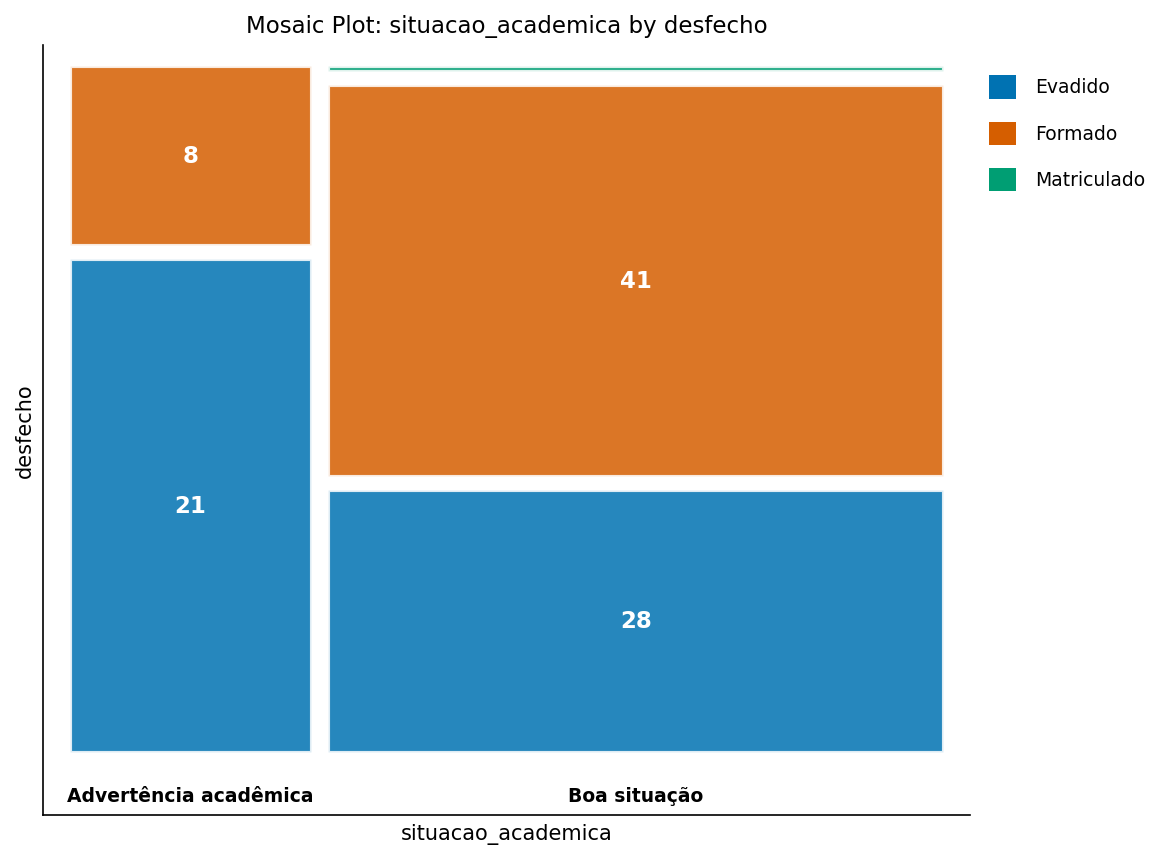

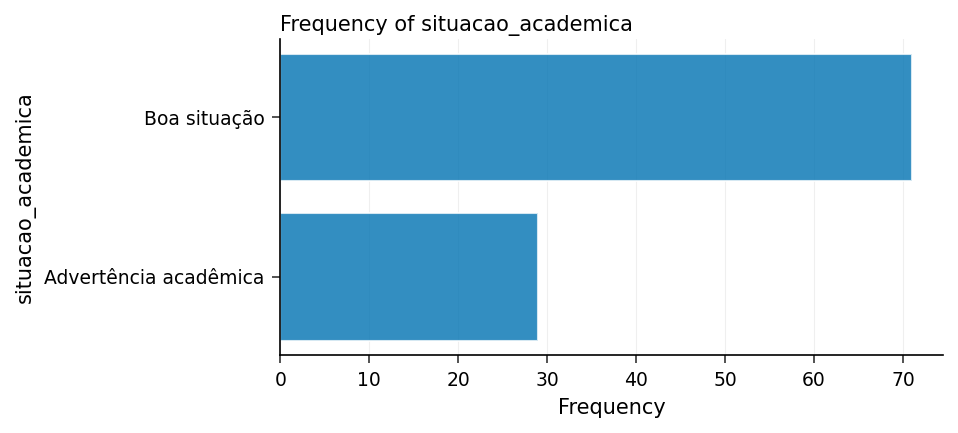

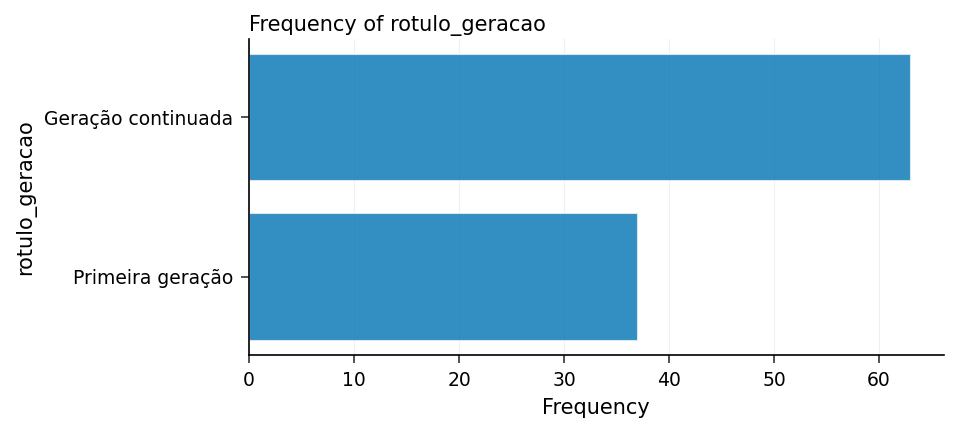

In [3]:
PROCEDIMENTO FREQUÊNCIAS DADOS=matriculas;
    TABLES situacao_academica*desfecho / chisq norow nocol nopercent;
    TABLES situacao_academica rotulo_geracao;
    RÓTULO situacao_academica="Situação acadêmica" desfecho="Desfecho" rotulo_geracao="Geração";
EXECUTAR;

## 4. Quando ocorrem as evasões? Percentis por situação

Para os estudantes que de fato evadiram, *quando* eles saíram? O **PROC UNIVARIATE** (restrito a `evadiu = 1`) reporta os percentis 10, 50 (mediana) e 90 do tempo até a evasão dentro de cada grupo de situação, gravados em um conjunto de dados de saída que então imprimimos. Isso descreve a dispersão do tempo de evasão sem supor uma distribuição.

A evasão mediana entre os estudantes que saíram ocorre por volta do semestre **2.4** (advertência acadêmica) versus **2.6** (boa situação) — próximos, porque *condicional à evasão*, ambos os grupos tendem a sair cedo. O efeito da situação, portanto, não é principalmente sobre *quando* uma evasão acontece, mas sobre *quantos* estudantes evadem e com que rapidez o conjunto de risco se afina, que é precisamente o que as curvas de Kaplan-Meier na próxima seção capturam.

In [4]:
PROCEDIMENTO UNIVARIATE DADOS=matriculas NOPRINT;
    ONDE evadiu = 1;
    CLASSE situacao_academica;
    VARIÁVEL tempo_semestres;
    SAÍDA out=ref_evasao pctlpts=10 50 90 pctlpre=t_ p=;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=ref_evasao noobs RÓTULO;
    TÍTULO "Percentis do tempo até a evasão (semestres), por situação acadêmica";
    RÓTULO situacao_academica="Situação acadêmica" t_10="P10 (semestres)" t_50="P50 (semestres)" t_90="P90 (semestres)";
EXECUTAR;
TÍTULO;

                          Percentis do tempo até a evasão (semestres), por situação acadêmica                           

     Situação acadêmica  P10 (semestres)  P50 (semestres)  P90 (semestres)
Advertência acadêmica                0.2              2.4              7.9
Boa situação                         0.4              2.6              8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset ref_evasao has 2 observations and 4 variables.
NOTE: PROC PRINT data=ref_evasao

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Curvas de evasão de Kaplan-Meier por situação acadêmica

Agora a etapa central de sobrevivência. O **PROC LIFETEST** estima a função sobrevivente **Kaplan-Meier** não paramétrica para o *tempo até a evasão*, tratando a formatura e a matrícula em andamento como censura (`evadiu(0)` marca as observações censuradas). Estratificar por `situacao_academica` produz uma curva de evasão por grupo, e `TEST=(LOGRANK WILCOXON)` executa dois testes complementares de se essas curvas diferem: o teste **log-rank** pondera todos os tempos de evento igualmente (sensível a diferenças tardias), enquanto o teste **Wilcoxon** dá mais peso aos tempos de evento precoces (sensível à evasão precoce). `PLOTS=SURVIVAL` solicita o gráfico sobreposto das curvas sobreviventes.

Ao longo da coorte há **49 eventos de evasão e 51 observações censuradas**. As curvas se separam claramente: os estudantes em advertência acadêmica atingem uma **sobrevivência mediana (tempo até a evasão) de 3.8 semestres**, enquanto os estudantes em boa situação duram mais que o dobro (**8.7 semestres**). Ambos os testes rejeitam a igualdade — **log-rank qui-quadrado = 10.73, *p* = 0.0011; Wilcoxon qui-quadrado = 7.66, *p* = 0.0056** — e as estatísticas comparáveis nos dizem que a diferença se sustenta por toda a janela de matrícula, não apenas em um pico inicial. O gráfico torna a mensagem imediata: a curva laranja de advertência acadêmica cai abruptamente ao longo dos primeiros quatro semestres, enquanto a curva azul de boa situação permanece alta.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Situação acadêmica = Advertência acadêmica

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.080


NOTE: PROC LIFETEST data=matriculas

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


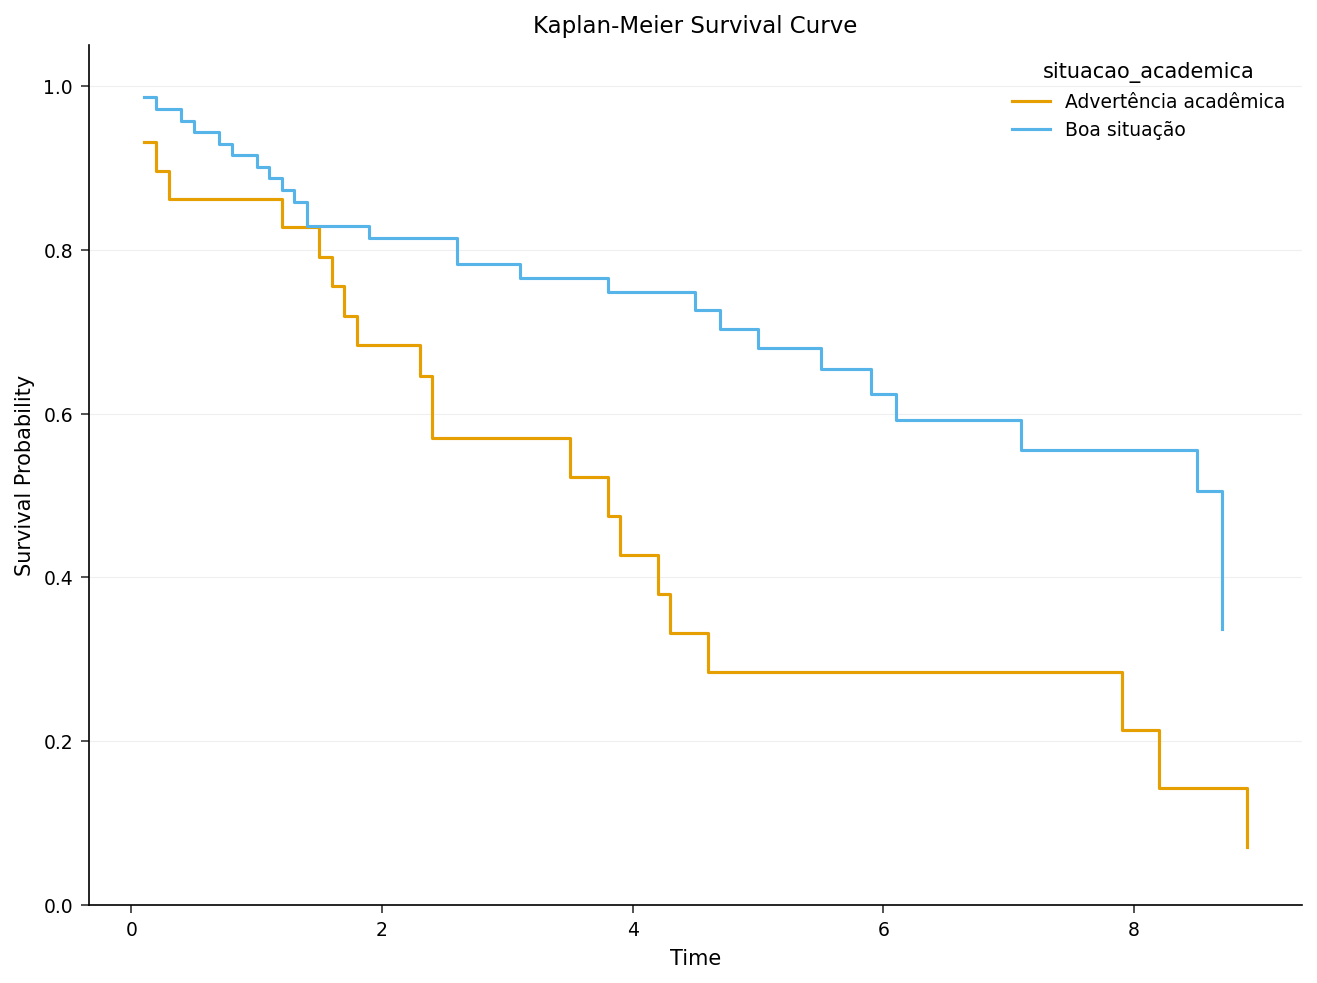

In [5]:
PROCEDIMENTO LIFETEST DADOS=matriculas PLOTS=SURVIVAL METHOD=km;
    TIME tempo_semestres*evadiu(0);
    STRATA situacao_academica / TEST=(logrank WILCOXON);
    RÓTULO situacao_academica="Situação acadêmica" tempo_semestres="Semestres até o evento";
EXECUTAR;

## 6. Modelo multivariável de riscos proporcionais de Cox para a evasão

O **PROC PHREG** ajusta o modelo de **riscos proporcionais de Cox** para o risco de evasão, ajustando os preditores simultaneamente. Solicitações principais:

- `evadiu(0)` faz da **evasão** o evento e de tudo o mais censura.
- `CLASS rotulo_geracao (ref="Geração continuada") / param=ref` codifica por referência o fator de primeira geração, de modo que sua razão de risco é lida em relação aos estudantes de geração continuada.
- `TIES=EFRON` é a aproximação recomendada para tratamento de empates quando vários estudantes saem no mesmo semestre.
- `RL` adiciona intervalos de confiança da razão de risco (limite de risco).
- A instrução `HAZARDRATIO` reporta o contraste de primeira geração contra o grupo de referência.

Uma razão de risco acima de 1 significa evasão *mais rápida* (maior risco); abaixo de 1 significa evasão *mais lenta* (protetora).

In [6]:
PROCEDIMENTO PHREG DADOS=matriculas;
    CLASSE rotulo_geracao (REF="Geração continuada") / PARAM=REF;
    MODELO tempo_semestres*evadiu(0) = gpa_ensino_medio gpa_semestre1 rotulo_geracao bolsa_pell
          / TIES=efron rl;
    hazardratio "Primeira geração vs continuada" rotulo_geracao / DIFF=REF;
    RÓTULO gpa_ensino_medio="GPA do ensino médio" gpa_semestre1="GPA do 1º semestre" rotulo_geracao="Geração" bolsa_pell="Bolsa Pell";
EXECUTAR;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                               Analysis of Maximum Likelihood Estimates                                                

Parameter                                DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
---------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------


NOTE: PROC PHREG data=matriculas

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretação e próximos passos

**Lendo a saída, de ponta a ponta:**

- O **PROC MEANS** confirma o sinal simulado: os estudantes que se formaram carregam um GPA do primeiro semestre mais alto (2.94 vs 2.54) e um GPA do ensino médio mais alto (3.10 vs 2.90) do que os estudantes que evadiram, e os estudantes ainda matriculados ficam no teto de 12 semestres — a censura à direita que os modelos de sobrevivência respeitam.
- O **PROC FREQ** mostra que a sinalização de advertência acadêmica do primeiro semestre acompanha o desfecho (21 de 29 estudantes sinalizados evadiram; 41 de 71 estudantes em boa situação se formaram; *p* = 0.0100), ao mesmo tempo em que sinaliza honestamente que o qui-quadrado é frágil em uma tabela de 100 estudantes com células esparsas.
- O **PROC UNIVARIATE** mostra que *condicional à evasão*, ambos os grupos saem cedo (mediana ~2.4–2.6 semestres); o efeito da situação é sobre quantos estudantes evadem e com que rapidez o conjunto de risco se afina, não sobre o tempo entre os que saem.
- O **PROC LIFETEST** entrega o destaque: curvas de evasão de Kaplan-Meier que se separam nitidamente por situação (mediana 3.8 vs 8.7 semestres; log-rank *p* = 0.0011, Wilcoxon *p* = 0.0056). A sinalização de alerta precoce é um discriminador genuíno e estatisticamente sustentado do tempo até a evasão.
- O **PROC PHREG** quantifica o efeito ajustado de cada preditor sobre o risco de evasão. Após o ajuste, o **GPA do primeiro semestre é o fator protetor mais forte** (razão de risco 0.21 por ponto de GPA, IC 95% 0.10–0.44, *p* < 0.0001): cada ponto adicional de GPA corta o risco de evasão em cerca de quatro quintos. O **GPA do ensino médio** também é protetor (HR 0.45, IC 95% 0.22–0.91, *p* = 0.027). Os **estudantes de primeira geração** enfrentam cerca do dobro do risco de evasão dos colegas de geração continuada com os mesmos GPAs (HR 2.03, IC 95% 1.07–3.84, *p* = 0.031). A **condição Pell não é significativa** uma vez controlado o GPA (HR 0.95, IC 95% 0.53–1.69, *p* = 0.85) — um lembrete útil de que um fator de risco bruto pode se dissipar após o ajuste. A hipótese nula global é decisivamente rejeitada (qui-quadrado da razão de verossimilhança = 31.11 com 4 gl, *p* < 0.0001).

**Como uma instituição agiria com base nisso.** O modelo de Cox produz um preditor linear por estudante (escore de risco) que ordena a coorte por risco de evasão; os estudantes de maior risco — baixo GPA no primeiro semestre combinado com condição de primeira geração — são encaminhados para orientação de alerta precoce em seus primeiros semestres, quando a intervenção é mais barata e mais eficaz. A comparação de Kaplan-Meier dá aos orientadores um critério único e defensável que eles já coletam ao final do primeiro semestre: a situação acadêmica.

**Ressalvas e extensões.** (1) Esta coorte sintética trata a formatura como censura para o modelo de evasão; com dados reais, formatura e evasão são genuínos **riscos concorrentes**, e uma extensão de riscos concorrentes (incidência cumulativa) via PROC PHREG `EVENTCODE=` evitaria superestimar a probabilidade de evasão. (2) A suposição de riscos proporcionais deve ser verificada (PHREG `ASSESS PH` ou resíduos de Schoenfeld) antes de confiar em uma única razão de risco ao longo de todos os semestres. (3) Covariáveis variáveis no tempo — GPA semestre a semestre, mudanças de auxílio financeiro, carga de disciplinas — são comuns em dados de retenção e são naturalmente tratadas por instruções de programação do PHREG. (4) A coorte de 100 estudantes aqui é dimensionada para o limite de execução sem licença; uma análise de produção carregaria vários milhares de estudantes, estreitando cada intervalo de confiança. Sempre valide um escore de risco implantado em uma coorte de teste retida antes de agir sobre ele operacionalmente.